<a href="https://colab.research.google.com/github/SO-HYBE/Uni-code/blob/main/Task_L06_Sohybe_Ibrahim_222250182.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sohybe Ibrahim Abdelwahab Amer
## 222250182

In [ ]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import LinearSVC

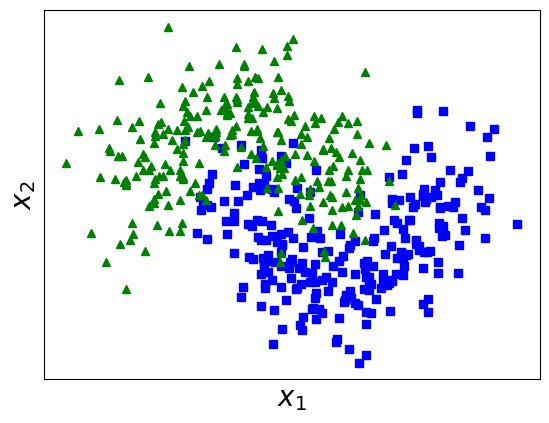

In [ ]:
# X are the generated instances, an array of shape (500,2).
# y are the labels of X, with values of either 0 or 1.
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

# 2- Visualizing the dataset.
from matplotlib import pyplot as plt

# When the label y is 0, the class is represented with a blue square.
# When the label y is 1, the class is represented with a green triangle.
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "g^")

# X contains two features, x1 and x2
plt.xlabel(r"$x_1$", fontsize=20)
plt.ylabel(r"$x_2$", fontsize=20)

# Simplifying the plot by removing the axis scales.
plt.xticks([])
plt.yticks([])

# Displaying the plot.
plt.show()

In [ ]:
X

array([[ 8.31039149e-01, -2.58748754e-01],
       [ 1.18506381e+00,  9.20387143e-01],
       [ 1.16402213e+00, -4.55525583e-01],
       [-2.36556013e-02,  1.08628844e+00],
       [ 4.80502733e-01,  1.50942444e+00],
       [ 1.31164912e+00, -5.51176060e-01],
       [ 1.16542367e+00, -1.58629894e-01],
       [ 1.56736404e-01,  1.31817168e+00],
       [ 4.53301022e-01,  4.96074925e-01],
       [ 1.65139719e+00, -4.59804351e-01],
       [ 1.02664982e+00, -1.56999382e-02],
       [-3.99677570e-01,  2.52192940e-01],
       [ 1.85352710e+00, -7.16418704e-01],
       [ 1.17564737e-01,  6.24869329e-01],
       [ 1.54123944e+00, -5.11050694e-01],
       [ 1.32833559e+00, -5.40696860e-01],
       [ 1.97170320e+00,  2.97790052e-01],
       [ 9.44441260e-01,  5.17911799e-01],
       [ 8.30619129e-01, -8.02099114e-01],
       [ 1.89343763e+00, -2.53611270e-01],
       [ 1.88323111e+00,  2.22375278e-01],
       [ 2.30801311e+00,  4.67930154e-01],
       [-3.89437608e-01,  2.39389050e-01],
       [ 1.

In [ ]:
X[:5]

array([[ 0.83103915, -0.25874875],
       [ 1.18506381,  0.92038714],
       [ 1.16402213, -0.45552558],
       [-0.0236556 ,  1.08628844],
       [ 0.48050273,  1.50942444]])

In [ ]:
y[:5]

array([1, 0, 1, 0, 0])

In [ ]:
polynomial_svm_clf = Pipeline([("poly_features", PolynomialFeatures(degree=5)),("scaler", StandardScaler()),("svm_clf", LinearSVC(C=5, loss="hinge"))])

In [ ]:
polynomial_svm_clf.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('poly_features', PolynomialFeatures(degree=5)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=5, loss='hinge'))])

In [ ]:
polynomial_svm_clf.predict([[1.18506381,  0.92038714]])

array([0])

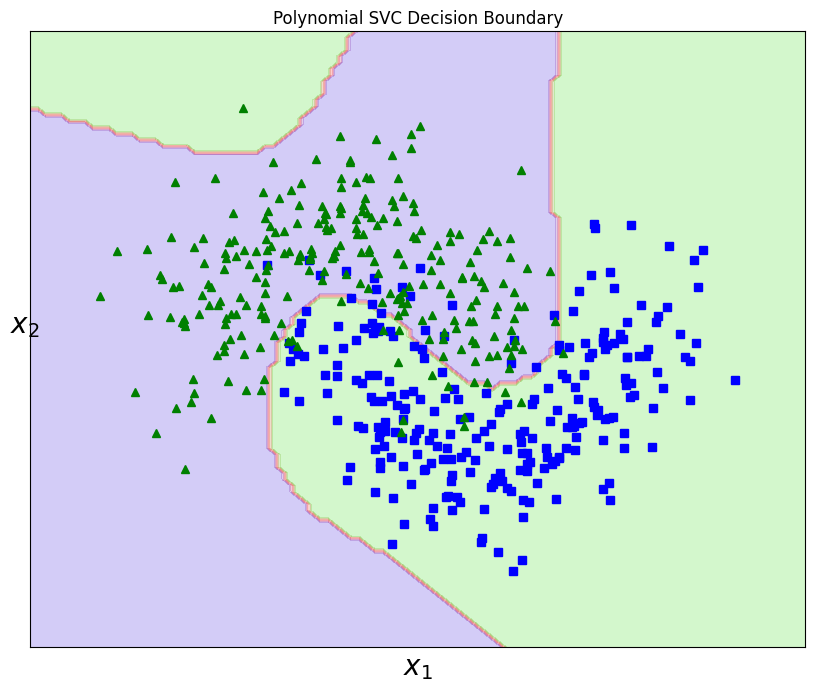

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_predictions(clf, X, y):
    x0s = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
    x1s = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X_new).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)

plt.figure(figsize=(10, 8))
plot_predictions(polynomial_svm_clf, X, y)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "g^")
plt.xlabel(r"$x_1$", fontsize=20)
plt.ylabel(r"$x_2$", fontsize=20, rotation=0)
plt.xticks([])
plt.yticks([])
plt.title("Polynomial SVC Decision Boundary")
plt.show()

#RBF Kernal

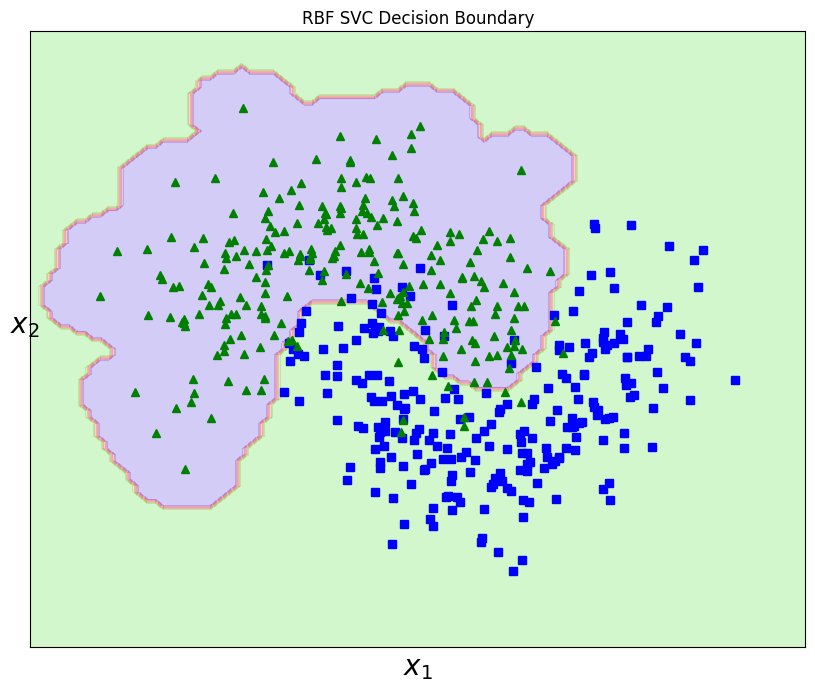

In [ ]:
from sklearn.svm import SVC

rbf_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="rbf", gamma=20, C=0.1))
])
rbf_kernel_svm_clf.fit(X, y)

plt.figure(figsize=(10, 8))
plot_predictions(rbf_kernel_svm_clf, X, y)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "g^")
plt.xlabel(r"$x_1$", fontsize=20)
plt.ylabel(r"$x_2$", fontsize=20, rotation=0)
plt.xticks([])
plt.yticks([])
plt.title("RBF SVC Decision Boundary")
plt.show()

# Task :Apply non linear SVM like SVC with an RBF kernel and other and compare results of linear and non linear SVC
# Using differernt evaluation metrics
# Loss functions in SVC

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
from sklearn.svm import SVC
from sklearn.datasets import make_moons

# Ensure data is generated
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the models for comparison
models = {
    "Linear SVC (Polynomial Features)": polynomial_svm_clf,
    "RBF Kernel SVC (gamma=20, C=0.1)": rbf_kernel_svm_clf,
    "RBF Kernel SVC (gamma=0.1, C=1000)": Pipeline([
        ("scaler", StandardScaler()),
        ("svm_clf", SVC(kernel="rbf", gamma=0.1, C=1000))
    ])
}

results = []

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)
display(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,Model,Accuracy,F1 Score
0,Linear SVC (Polynomial Features),0.89,0.895238
1,"RBF Kernel SVC (gamma=20, C=0.1)",0.72,0.674419
2,"RBF Kernel SVC (gamma=0.1, C=1000)",0.88,0.884615


### Comparison Analysis
The table above shows the evaluation metrics for the different SVM kernels. Generally, non-linear kernels like RBF perform better on the 'moons' dataset because the decision boundary is inherently non-linear. The 'gamma' parameter in RBF controls the reach of a single training instance, while 'C' controls the trade-off between smooth decision boundaries and classifying training points correctly.